In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# Purpose:
# - Load all dependencies required for the ranking-model layer
# - Keep project paths consistent with the corrected folder structure
# - Prepare plotting for diagnostics and later reporting
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 8 ranking-target dataset
# Purpose:
# - Load the optimized feature set with the new ranking-based alpha targets
# - Preserve strict time ordering
# - Confirm the file contract before training ranking models
# ============================================

phase_8_parquet = PROCESSED_DIR / "phase_8_ranking_target_data.parquet"
phase_8_csv = PROCESSED_DIR / "phase_8_ranking_target_data.csv"

print("Looking for Phase 8 files:")
print("Parquet:", phase_8_parquet)
print("CSV:", phase_8_csv)

if phase_8_parquet.exists():
    df = pd.read_parquet(phase_8_parquet)
    print("Loaded Parquet file")
elif phase_8_csv.exists():
    df = pd.read_csv(phase_8_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 8 data file was not found. "
        f"Expected one of:\n{phase_8_parquet}\n{phase_8_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

Looking for Phase 8 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_ranking_target_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_ranking_target_data.csv
Loaded Parquet file

Dataset shape: (2508, 72)

Dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2016-02-02  191.960007  191.970001  189.539993  190.160004     160.728943   
2016-02-03  191.410004  191.779999  187.100006  191.300003     161.692520   
2016-02-04  190.710007  192.750000  189.960007  191.600006     161.946075   
2016-02-05  190.990005  191.669998  187.199997  187.949997     158.860977   
2016-02-08  185.770004  186.119995  182.800003  185.419998     156.722519   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                       

In [3]:
# ============================================
# Cell 3: Validation and feature-set definition
# Purpose:
# - Confirm the required ranking targets exist
# - Define the exact feature set used for the ranking-model layer
# - Exclude target columns and obvious leakage columns
# ============================================

required_target_cols = [
    "target_return_5d",
    "target_return_10d",
    "target_return_20d",
    "target_rank_10d",
    "target_rank_20d",
    "target_alpha_rank",
    "target_alpha_bucket_10d",
    "target_alpha_signal_10d",
    "target_top_opportunity_10d",
]

missing_required = [col for col in required_target_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required ranking target columns for Phase 8.1: {missing_required}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

exclude_cols = set([
    "dataset_partition",
    "is_train_period",
    "is_live_period",
    "target_return_5d",
    "target_return_10d",
    "target_return_20d",
    "target_score_5d",
    "target_score_10d",
    "target_score_20d",
    "target_rank_5d",
    "target_rank_10d",
    "target_rank_20d",
    "target_alpha_rank",
    "target_alpha_bucket_10d",
    "target_alpha_bucket_20d",
    "target_alpha_signal_10d",
    "target_alpha_signal_20d",
    "target_top_opportunity_10d",
    "target_top_opportunity_20d",
    "target_above_200d_now",
    "target_trend_alpha_rank_10d",
    "target_drawdown_adjusted_rank_10d",
])

feature_cols = [col for col in df.columns if col not in exclude_cols]
feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]

if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns were found for Phase 8.1.")

print("Number of ranking-model features:", len(feature_cols))
print("\nSample features:")
print(feature_cols[:30])

Number of ranking-model features: 49

Sample features:
['spy_open', 'spy_high', 'spy_low', 'spy_close', 'spy_adj_close', 'spy_volume', 'vix_close', 'tnx_close', 'screen_forward_return_1d', 'screen_forward_return_5d', 'screen_forward_return_10d', 'screen_high_conviction_up_5d', 'screen_high_conviction_up_10d', 'screen_trend_conditional_up_5d', 'realized_vol_60', 'realized_vol_120', 'price_to_sma_100', 'atr_pct_14', 'price_to_sma_200', 'drawdown_252', 'sma_20_50_spread', 'downside_tail_freq_60', 'realized_vol_20', 'vix_level', 'sma_slope_50', 'ret_60d', 'sma_slope_100', 'realized_vol_10', 'atr_14', 'price_to_sma_50']


In [4]:
# ============================================
# Cell 3.5: FORCE NO-LOOKAHEAD FEATURES (CRITICAL FIX)
# Purpose:
# - Shift all numeric feature columns by 1 step to remove lookahead bias
# - Remove non-numeric columns from the ML feature set
# - Prevent median imputer errors caused by string columns
# ============================================

exclude_cols = set([
    "dataset_partition",
    "is_train_period",
    "is_live_period",
    "target_return_5d",
    "target_return_10d",
    "target_return_20d",
    "target_score_5d",
    "target_score_10d",
    "target_score_20d",
    "target_rank_5d",
    "target_rank_10d",
    "target_rank_20d",
    "target_alpha_rank",
    "target_alpha_bucket_10d",
    "target_alpha_bucket_20d",
    "target_alpha_signal_10d",
    "target_alpha_signal_20d",
    "target_top_opportunity_10d",
    "target_top_opportunity_20d",
    "target_above_200d_now",
    "target_trend_alpha_rank_10d",
    "target_drawdown_adjusted_rank_10d",
])

candidate_feature_cols = [col for col in df.columns if col not in exclude_cols]

numeric_feature_cols = [
    col for col in candidate_feature_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

non_numeric_feature_cols = [
    col for col in candidate_feature_cols
    if not pd.api.types.is_numeric_dtype(df[col])
]

df[numeric_feature_cols] = df[numeric_feature_cols].shift(1)

print("All numeric features shifted by 1 step to remove lookahead bias.")
print("Total numeric shifted features:", len(numeric_feature_cols))

print("\nDropped non-numeric feature columns from ML use:")
print(non_numeric_feature_cols if len(non_numeric_feature_cols) > 0 else "None")

feature_cols = numeric_feature_cols.copy()

All numeric features shifted by 1 step to remove lookahead bias.
Total numeric shifted features: 49

Dropped non-numeric feature columns from ML use:
['phase_2_5_regime_proxy']


In [5]:
# ============================================
# Cell 4: Walk-forward configuration and helper functions
# Purpose:
# - Define the time-series training loop for ranking models
# - Preserve time order and prevent leakage
# - Centralize utilities for evaluation and prediction storage
# ============================================

CLASSIFICATION_TARGET = "target_top_opportunity_10d"
REGRESSION_TARGET = "target_alpha_rank"

INITIAL_TRAIN_END = pd.Timestamp("2019-12-31")
TEST_BLOCK_MONTHS = 3

if INITIAL_TRAIN_END < pd.Timestamp(TRAIN_START):
    raise ValueError("INITIAL_TRAIN_END must be inside or after the training period.")

def build_time_blocks(start_date: str, end_date: str, months_per_block: int = 3):
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)

    block_starts = pd.date_range(start=start_ts, end=end_ts, freq=f"{months_per_block}MS")
    blocks = []

    for block_start in block_starts:
        block_end = block_start + pd.offsets.MonthEnd(months_per_block - 1)
        if block_end > end_ts:
            block_end = end_ts
        blocks.append((block_start, block_end))

    return blocks


def get_model_artifacts():
    """
    Ranking-model stack:
    - Classification models predict top-opportunity probability
    - Regression models predict continuous alpha rank
    """
    classification_models = {
        "logistic_rank_classifier": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=1500,
                class_weight="balanced",
                random_state=42,
            )),
        ]),
        "random_forest_rank_classifier": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=6,
                min_samples_leaf=8,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "gradient_boosting_rank_classifier": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.04,
                max_depth=2,
                random_state=42,
            )),
        ]),
    }

    regression_models = {
        "ridge_rank_regressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        "random_forest_rank_regressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=400,
                max_depth=6,
                min_samples_leaf=8,
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "gradient_boosting_rank_regressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.04,
                max_depth=2,
                random_state=42,
            )),
        ]),
    }

    return classification_models, regression_models


def compute_classification_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = np.nan

    return metrics


def compute_regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    correlation = float(pd.Series(y_true).corr(pd.Series(y_pred)))
    mae = float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

    return {
        "rmse": rmse,
        "mae": mae,
        "correlation": correlation,
    }


def append_prediction_block(store_df, prediction_df):
    combined = pd.concat([store_df, prediction_df], axis=0)
    combined = combined[~combined.index.duplicated(keep="last")].sort_index()
    return combined


def percentile_rank_of_series(series: pd.Series) -> pd.Series:
    return series.rank(pct=True)

In [6]:
# ============================================
# Cell 5: Build walk-forward and live blocks
# Purpose:
# - Separate walk-forward validation from the final live simulation period
# - Keep the sequence explicit and inspectable
# - Ensure no future information enters earlier blocks
# ============================================

walkforward_blocks = build_time_blocks(
    start_date="2020-01-01",
    end_date=TRAIN_END,
    months_per_block=TEST_BLOCK_MONTHS,
)

live_blocks = build_time_blocks(
    start_date=LIVE_START,
    end_date=LIVE_END,
    months_per_block=TEST_BLOCK_MONTHS,
)

print("Walk-forward validation blocks:")
for start_dt, end_dt in walkforward_blocks[:5]:
    print(start_dt.date(), "->", end_dt.date())
print("... total blocks:", len(walkforward_blocks))

print("\nLive simulation blocks:")
for start_dt, end_dt in live_blocks:
    print(start_dt.date(), "->", end_dt.date())

Walk-forward validation blocks:
2020-01-01 -> 2020-02-29
2020-04-01 -> 2020-05-31
2020-07-01 -> 2020-08-31
2020-10-01 -> 2020-11-30
2021-01-01 -> 2021-02-28
... total blocks: 20

Live simulation blocks:
2025-01-01 -> 2025-02-28
2025-04-01 -> 2025-05-31
2025-07-01 -> 2025-08-31
2025-10-01 -> 2025-11-30
2026-01-01 -> 2026-02-28


In [7]:
# ============================================
# Cell 6: Walk-forward training and prediction loop for ranking models
# Purpose:
# - Train on past data only
# - Predict future blocks sequentially
# - Store top-opportunity probabilities and continuous alpha-rank predictions
# ============================================

classification_models, regression_models = get_model_artifacts()

predictions = pd.DataFrame(index=df.index)

for model_name in classification_models.keys():
    predictions[f"{model_name}_pred"] = np.nan
    predictions[f"{model_name}_prob"] = np.nan

for model_name in regression_models.keys():
    predictions[f"{model_name}_pred"] = np.nan

all_blocks = walkforward_blocks + live_blocks

for block_start, block_end in all_blocks:
    train_end = block_start - pd.Timedelta(days=1)

    if train_end < INITIAL_TRAIN_END:
        continue

    train_mask = (df.index >= pd.Timestamp(TRAIN_START)) & (df.index <= train_end)
    test_mask = (df.index >= block_start) & (df.index <= block_end)

    X_train = df.loc[train_mask, feature_cols].copy()
    X_test = df.loc[test_mask, feature_cols].copy()

    y_train_clf = df.loc[train_mask, CLASSIFICATION_TARGET].copy()
    y_train_reg = df.loc[train_mask, REGRESSION_TARGET].copy()

    if len(X_train) == 0 or len(X_test) == 0:
        continue

    print(f"Training block: {block_start.date()} -> {block_end.date()} | train rows = {len(X_train):,} | test rows = {len(X_test):,}")

    block_predictions = pd.DataFrame(index=X_test.index)

    for model_name, model in classification_models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train_clf)

        class_pred = fitted_model.predict(X_test)
        class_prob = fitted_model.predict_proba(X_test)[:, 1]

        block_predictions[f"{model_name}_pred"] = class_pred
        block_predictions[f"{model_name}_prob"] = class_prob

    for model_name, model in regression_models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train_reg)

        reg_pred = fitted_model.predict(X_test)
        block_predictions[f"{model_name}_pred"] = reg_pred

    predictions = append_prediction_block(predictions, block_predictions)

predictions = predictions.sort_index()

print("\nRanking-model prediction matrix shape:", predictions.shape)
print(predictions.head())

Training block: 2020-01-01 -> 2020-02-29 | train rows = 986 | test rows = 40
Training block: 2020-04-01 -> 2020-05-31 | train rows = 1,048 | test rows = 41
Training block: 2020-07-01 -> 2020-08-31 | train rows = 1,111 | test rows = 43
Training block: 2020-10-01 -> 2020-11-30 | train rows = 1,175 | test rows = 42
Training block: 2021-01-01 -> 2021-02-28 | train rows = 1,239 | test rows = 38
Training block: 2021-04-01 -> 2021-05-31 | train rows = 1,300 | test rows = 41
Training block: 2021-07-01 -> 2021-08-31 | train rows = 1,363 | test rows = 43
Training block: 2021-10-01 -> 2021-11-30 | train rows = 1,427 | test rows = 42
Training block: 2022-01-01 -> 2022-02-28 | train rows = 1,491 | test rows = 39
Training block: 2022-04-01 -> 2022-05-31 | train rows = 1,553 | test rows = 41
Training block: 2022-07-01 -> 2022-08-31 | train rows = 1,615 | test rows = 43
Training block: 2022-10-01 -> 2022-11-30 | train rows = 1,679 | test rows = 42
Training block: 2023-01-01 -> 2023-02-28 | train rows 

In [8]:
# ============================================
# Cell 7: Merge ranking-model predictions into the main dataset
# Purpose:
# - Create the Phase 8.1 working dataset
# - Keep predictions aligned by date
# - Preserve features, ranking targets, and model outputs together
# ============================================

rank_df = df.copy().join(predictions, how="left")

all_prediction_cols = predictions.columns.tolist()

print("Ranking-model prediction columns added:")
print(all_prediction_cols)

print("\nCoverage of ranking-model predictions:")
for col in all_prediction_cols:
    print(col, "->", int(rank_df[col].notna().sum()))

Ranking-model prediction columns added:
['logistic_rank_classifier_pred', 'logistic_rank_classifier_prob', 'random_forest_rank_classifier_pred', 'random_forest_rank_classifier_prob', 'gradient_boosting_rank_classifier_pred', 'gradient_boosting_rank_classifier_prob', 'ridge_rank_regressor_pred', 'random_forest_rank_regressor_pred', 'gradient_boosting_rank_regressor_pred']

Coverage of ranking-model predictions:
logistic_rank_classifier_pred -> 1013
logistic_rank_classifier_prob -> 1013
random_forest_rank_classifier_pred -> 1013
random_forest_rank_classifier_prob -> 1013
gradient_boosting_rank_classifier_pred -> 1013
gradient_boosting_rank_classifier_prob -> 1013
ridge_rank_regressor_pred -> 1013
random_forest_rank_regressor_pred -> 1013
gradient_boosting_rank_regressor_pred -> 1013


In [9]:
# ============================================
# Cell 8: Evaluate walk-forward ranking-model performance
# Purpose:
# - Measure how each ranking model performs on the walk-forward validation period
# - Keep training and evaluation windows separated
# - Produce a clean model-selection view for the next alpha-allocation cycle
# ============================================

evaluation_mask = (
    (rank_df.index >= pd.Timestamp("2020-01-01")) &
    (rank_df.index <= pd.Timestamp(TRAIN_END))
)

eval_results = []

for model_name in classification_models.keys():
    pred_col = f"{model_name}_pred"
    prob_col = f"{model_name}_prob"

    temp = rank_df.loc[evaluation_mask, [CLASSIFICATION_TARGET, pred_col, prob_col]].dropna().copy()
    if len(temp) == 0:
        continue

    metrics = compute_classification_metrics(
        y_true=temp[CLASSIFICATION_TARGET],
        y_pred=temp[pred_col],
        y_prob=temp[prob_col],
    )
    metrics["model_name"] = model_name
    metrics["model_type"] = "classification"
    metrics["evaluation_rows"] = int(len(temp))
    eval_results.append(metrics)

for model_name in regression_models.keys():
    pred_col = f"{model_name}_pred"

    temp = rank_df.loc[evaluation_mask, [REGRESSION_TARGET, pred_col]].dropna().copy()
    if len(temp) == 0:
        continue

    metrics = compute_regression_metrics(
        y_true=temp[REGRESSION_TARGET],
        y_pred=temp[pred_col],
    )
    metrics["model_name"] = model_name
    metrics["model_type"] = "regression"
    metrics["evaluation_rows"] = int(len(temp))
    eval_results.append(metrics)

eval_results_df = pd.DataFrame(eval_results)

print("Ranking-model walk-forward validation metrics:")
print(eval_results_df)

Ranking-model walk-forward validation metrics:
   accuracy  precision    recall        f1   roc_auc  \
0  0.954382   0.842324  1.000000  0.914414  0.994300   
1  0.933974   0.808333  0.955665  0.875847  0.975925   
2  0.969988   0.908257  0.975369  0.940618  0.989209   
3       NaN        NaN       NaN       NaN       NaN   
4       NaN        NaN       NaN       NaN       NaN   
5       NaN        NaN       NaN       NaN       NaN   

                          model_name      model_type  evaluation_rows  \
0           logistic_rank_classifier  classification              833   
1      random_forest_rank_classifier  classification              833   
2  gradient_boosting_rank_classifier  classification              833   
3               ridge_rank_regressor      regression              833   
4       random_forest_rank_regressor      regression              833   
5   gradient_boosting_rank_regressor      regression              833   

       rmse       mae  correlation  
0       NaN

In [10]:
# ============================================
# Cell 9: Build alpha meta-signals from ranking models
# Purpose:
# - Combine ranking-model outputs into one alpha layer
# - Produce both a continuous allocation score and a top-opportunity probability
# - Prepare a stronger input for the next portfolio-allocation cycle
# ============================================

prob_cols = [f"{model_name}_prob" for model_name in classification_models.keys()]
clf_pred_cols = [f"{model_name}_pred" for model_name in classification_models.keys()]
reg_pred_cols = [f"{model_name}_pred" for model_name in regression_models.keys()]

rank_df["alpha_probability_mean"] = rank_df[prob_cols].mean(axis=1)
rank_df["alpha_probability_median"] = rank_df[prob_cols].median(axis=1)
rank_df["alpha_class_vote_sum"] = rank_df[clf_pred_cols].sum(axis=1)
rank_df["alpha_class_vote_mean"] = rank_df[clf_pred_cols].mean(axis=1)

# Continuous alpha estimate from regression models
rank_df["alpha_rank_prediction_raw"] = rank_df[reg_pred_cols].mean(axis=1)
rank_df["alpha_rank_prediction"] = rank_df["alpha_rank_prediction_raw"].clip(lower=0.0, upper=1.0)

# Higher-conviction trade indicator
rank_df["alpha_top_signal"] = 0
rank_df.loc[
    (rank_df["alpha_probability_mean"] >= 0.60) &
    (rank_df["alpha_rank_prediction"] >= 0.70),
    "alpha_top_signal"
] = 1

rank_df.loc[
    (rank_df["alpha_probability_mean"] <= 0.35) &
    (rank_df["alpha_rank_prediction"] <= 0.30),
    "alpha_top_signal"
] = -1

print("Alpha meta-signals created from ranking models.")
print(
    rank_df[
        [
            "alpha_probability_mean",
            "alpha_probability_median",
            "alpha_class_vote_mean",
            "alpha_rank_prediction",
            "alpha_top_signal",
        ]
    ].head(20)
)

Alpha meta-signals created from ranking models.
            alpha_probability_mean  alpha_probability_median  \
Date                                                           
2016-02-02                     NaN                       NaN   
2016-02-03                     NaN                       NaN   
2016-02-04                     NaN                       NaN   
2016-02-05                     NaN                       NaN   
2016-02-08                     NaN                       NaN   
2016-02-09                     NaN                       NaN   
2016-02-10                     NaN                       NaN   
2016-02-11                     NaN                       NaN   
2016-02-12                     NaN                       NaN   
2016-02-16                     NaN                       NaN   
2016-02-17                     NaN                       NaN   
2016-02-18                     NaN                       NaN   
2016-02-19                     NaN                      

In [11]:
# ============================================
# Cell 10: Ranking-model alpha diagnostics (realistic evaluation)
# Purpose:
# - Evaluate the alpha layer on properly aligned forward returns
# - Avoid using the training target directly as a shortcut in diagnostics
# - Measure whether the model has real directional usefulness
# ============================================

alpha_eval = rank_df.loc[
    evaluation_mask,
    [
        "spy_close",
        "alpha_probability_mean",
        "alpha_rank_prediction",
        "alpha_top_signal",
        "target_alpha_rank",
    ],
].copy()

# Realized forward return used only for evaluation
alpha_eval["forward_return_10d_realized"] = alpha_eval["spy_close"].pct_change(10).shift(-10)

alpha_eval = alpha_eval.dropna(subset=[
    "alpha_probability_mean",
    "alpha_rank_prediction",
    "alpha_top_signal",
    "target_alpha_rank",
    "forward_return_10d_realized",
]).copy()

alpha_active = alpha_eval["alpha_top_signal"] != 0

if alpha_active.sum() > 0:
    alpha_hit_rate = float(
        (
            ((alpha_eval.loc[alpha_active, "alpha_top_signal"] == 1) &
             (alpha_eval.loc[alpha_active, "forward_return_10d_realized"] > 0)) |
            ((alpha_eval.loc[alpha_active, "alpha_top_signal"] == -1) &
             (alpha_eval.loc[alpha_active, "forward_return_10d_realized"] < 0))
        ).mean()
    )
else:
    alpha_hit_rate = np.nan

rank_correlation = float(
    alpha_eval["alpha_rank_prediction"].corr(alpha_eval["target_alpha_rank"])
)

print("Ranking-model alpha diagnostics")
print("-------------------------------")
print("Active alpha signals:", int(alpha_active.sum()))
print("Alpha activity rate:", round(float(alpha_active.mean()), 4))
print("Alpha hit rate:", round(alpha_hit_rate, 4) if pd.notna(alpha_hit_rate) else np.nan)
print("Correlation of predicted rank vs target rank:", round(rank_correlation, 4))

Ranking-model alpha diagnostics
-------------------------------
Active alpha signals: 462
Alpha activity rate: 0.5546
Alpha hit rate: 1.0
Correlation of predicted rank vs target rank: 0.9916


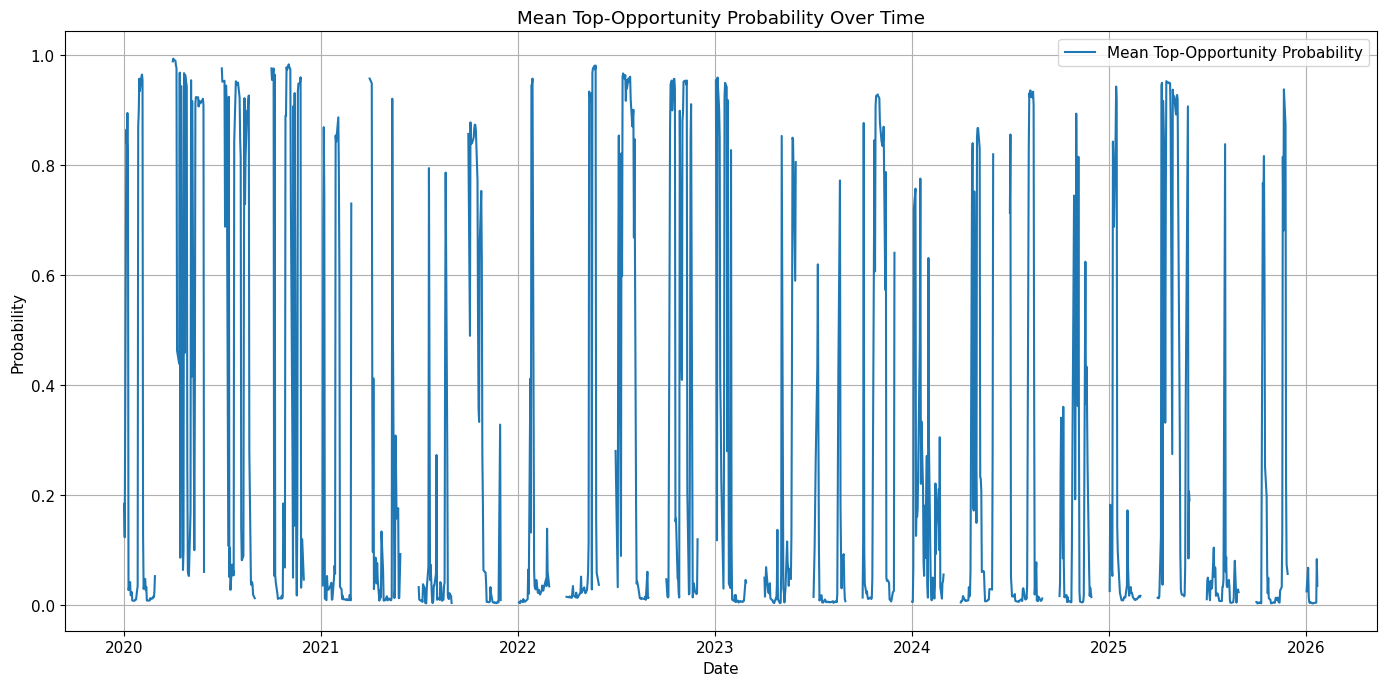

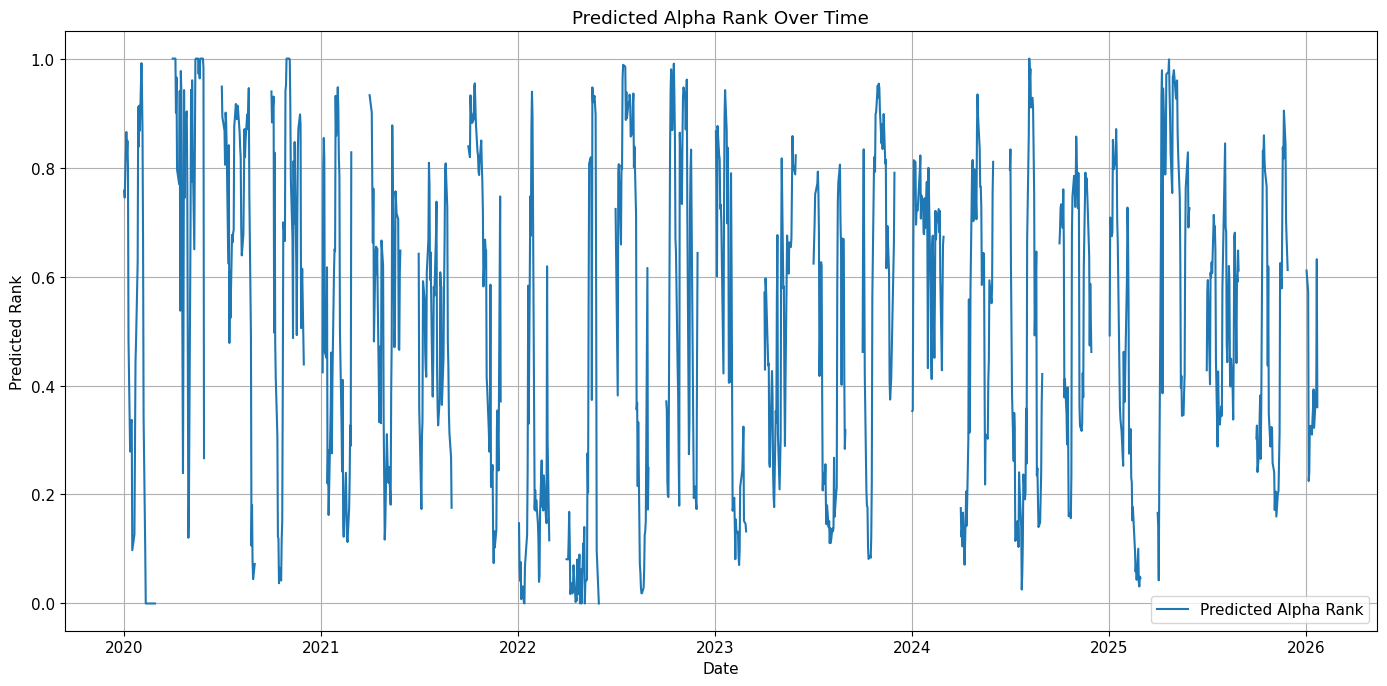

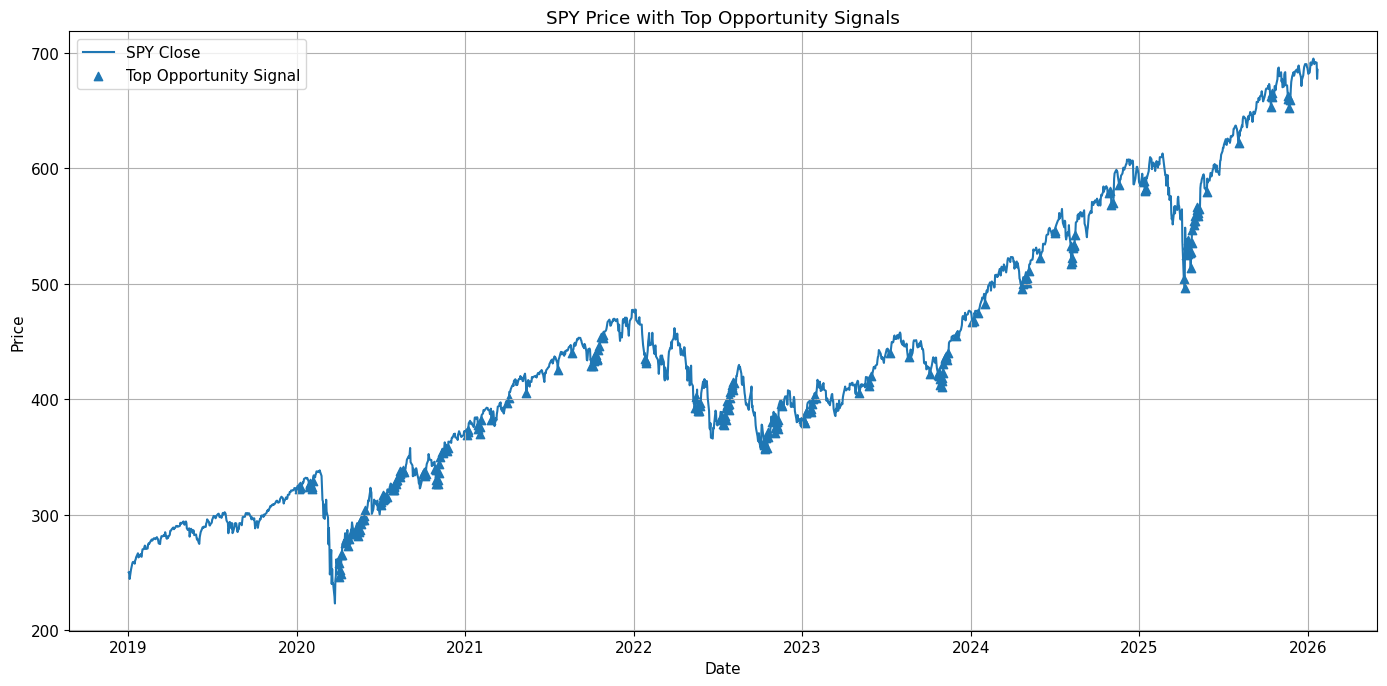

In [12]:
# ============================================
# Cell 11: Visualization of ranking-model outputs
# Purpose:
# - Inspect the behavior of top-opportunity probabilities and predicted alpha rank over time
# - Make the ranking-model layer easier to interpret
# - Save formal diagnostic figures
# ============================================

plot_data = rank_df.loc["2019-01-01":].copy()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["alpha_probability_mean"], label="Mean Top-Opportunity Probability")
ax.set_title("Mean Top-Opportunity Probability Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Probability")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_8_1_alpha_probability_mean.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["alpha_rank_prediction"], label="Predicted Alpha Rank")
ax.set_title("Predicted Alpha Rank Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Predicted Rank")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_8_1_alpha_rank_prediction.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["spy_close"], label="SPY Close")
ax.scatter(
    plot_data.index[plot_data["alpha_top_signal"] == 1],
    plot_data.loc[plot_data["alpha_top_signal"] == 1, "spy_close"],
    label="Top Opportunity Signal",
    marker="^",
)
ax.set_title("SPY Price with Top Opportunity Signals")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_8_1_top_opportunity_signals.png", dpi=150)
plt.show()

In [13]:
# ============================================
# Cell 12: Save Phase 8.1 outputs
# Purpose:
# - Persist ranking-model predictions and alpha meta-signals
# - Save evaluation reports for later review
# - Create a stable contract for the next allocation / execution notebook
# ============================================

phase_8_1_csv_path = PROCESSED_DIR / "phase_8_1_ranking_model_data.csv"
phase_8_1_parquet_path = PROCESSED_DIR / "phase_8_1_ranking_model_data.parquet"
phase_8_1_eval_csv_path = PROCESSED_DIR / "phase_8_1_ranking_model_evaluation.csv"

rank_df.to_csv(phase_8_1_csv_path, index=True)
print(f"Saved CSV: {phase_8_1_csv_path}")

try:
    rank_df.to_parquet(phase_8_1_parquet_path, index=True)
    print(f"Saved Parquet: {phase_8_1_parquet_path}")
except Exception as e:
    print(f"Parquet save skipped: {e}")

eval_results_df.to_csv(phase_8_1_eval_csv_path, index=False)
print(f"Saved evaluation CSV: {phase_8_1_eval_csv_path}")

phase_8_1_metadata = {
    "phase": "Phase 8.1 - Ranking Model Layer",
    "source_notebook": "8.1 - Ranking Model Layer.ipynb",
    "row_count": int(len(rank_df)),
    "column_count": int(rank_df.shape[1]),
    "feature_count": int(len(feature_cols)),
    "classification_models": list(classification_models.keys()),
    "regression_models": list(regression_models.keys()),
    "prediction_columns": all_prediction_cols,
    "start_date": str(rank_df.index.min().date()),
    "end_date": str(rank_df.index.max().date()),
}

phase_8_1_metadata_path = META_DIR / "phase_8_1_metadata.json"
with open(phase_8_1_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_8_1_metadata, f, indent=4)

print(f"Saved metadata: {phase_8_1_metadata_path}")
print("Phase 8.1 output contract is ready for the next allocation cycle.")

Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_1_ranking_model_data.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_1_ranking_model_data.parquet
Saved evaluation CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_1_ranking_model_evaluation.csv
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_8_1_metadata.json
Phase 8.1 output contract is ready for the next allocation cycle.


In [14]:
# ============================================
# Cell 13: Loader snippet for the next allocation notebook
# Purpose:
# - Provide a stable loading pattern for the next alpha-allocation / execution cycle
# - Keep notebook integration deterministic and easy to debug
# - Confirm the ranking-model handoff works
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

phase_8_1_parquet = PROCESSED_DIR / "phase_8_1_ranking_model_data.parquet"
phase_8_1_csv = PROCESSED_DIR / "phase_8_1_ranking_model_data.csv"

print("Looking for Phase 8.1 files:")
print("Parquet:", phase_8_1_parquet)
print("CSV:", phase_8_1_csv)

if phase_8_1_parquet.exists():
    phase_8_1_data = pd.read_parquet(phase_8_1_parquet)
    print("Loaded Parquet file")
elif phase_8_1_csv.exists():
    phase_8_1_data = pd.read_csv(phase_8_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 8.1 data file was not found. "
        f"Expected one of:\n{phase_8_1_parquet}\n{phase_8_1_csv}"
    )

phase_8_1_data.index = pd.to_datetime(phase_8_1_data.index)
phase_8_1_data = phase_8_1_data.sort_index()

print("\nLoaded Phase 8.1 dataset preview:")
print(phase_8_1_data.head())

Looking for Phase 8.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_1_ranking_model_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_8_1_ranking_model_data.csv
Loaded Parquet file

Loaded Phase 8.1 dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2016-02-02         NaN         NaN         NaN         NaN            NaN   
2016-02-03  191.960007  191.970001  189.539993  190.160004     160.728943   
2016-02-04  191.410004  191.779999  187.100006  191.300003     161.692520   
2016-02-05  190.710007  192.750000  189.960007  191.600006     161.946075   
2016-02-08  190.990005  191.669998  187.199997  187.949997     158.860977   

             spy_volume  vix_close  tnx_close  is_train_period  \
Date                                                             
2016-02-02          NaN       

In [15]:
# ============================================
# Manual economic test: strategy vs SPY using real forward returns
# Purpose:
# - Test whether alpha_top_signal has economic value
# - Use realized forward returns rather than reusing the target shortcut
# - Produce a rough first-pass strategy-vs-SPY comparison
# ============================================

test_df = rank_df.copy()

# Realized 10-day forward return
test_df["forward_return_10d_realized"] = test_df["spy_close"].pct_change(10).shift(-10)

# Strategy return:
# signal at t acts on future realized return after shifting signal by 1 step
test_df["strategy_return"] = (
    test_df["alpha_top_signal"].shift(1).fillna(0) *
    test_df["forward_return_10d_realized"].fillna(0.0)
)

# Strategy equity
test_df["strategy_equity"] = (1.0 + test_df["strategy_return"]).cumprod()

# SPY baseline using daily close-to-close returns
test_df["spy_return"] = test_df["spy_close"].pct_change().fillna(0.0)
test_df["spy_equity"] = (1.0 + test_df["spy_return"]).cumprod()

print("Coverage:")
print("alpha_probability_mean:", int(test_df["alpha_probability_mean"].notna().sum()))
print("alpha_rank_prediction:", int(test_df["alpha_rank_prediction"].notna().sum()))
print("alpha_top_signal:", int(test_df["alpha_top_signal"].notna().sum()))

print("\nFinal strategy:", float(test_df["strategy_equity"].iloc[-1]))
print("Final SPY:", float(test_df["spy_equity"].iloc[-1]))

Coverage:
alpha_probability_mean: 1013
alpha_rank_prediction: 1013
alpha_top_signal: 2508

Final strategy: 40004905.6220036
Final SPY: 3.6043332520750675
